# Pertemuan 6 — Persiapan Data

**Mata Kuliah:** Pengantar Data Science (Kode: 200302305)  
**Program Studi:** PJJ Informatika  
**Semester:** 4  
**Dosen:** Syahid Abdullah, S.Si, M.Kom

---

**Nama :** Junior Dany Wibisono  
**NIM  :** 250401020098  
**Kelas :** IF401  
**Angkatan:** 2025  
**Tanggal:** 26 Mei 2026

---

## Tujuan Notebook
Notebook ini dibuat sebagai aktivitas hands-on Pertemuan 6 untuk:
1. Memahami mengapa data mentah tidak bisa langsung dimasukkan ke model Machine Learning
2. Menerapkan **Label Encoding**, **One-Hot Encoding**, dan **Ordinal Encoding** menggunakan Pandas & scikit-learn
3. Menerapkan **MinMaxScaler**, **StandardScaler**, dan **RobustScaler** dan memahami perbedaannya
4. Membagi dataset menjadi training set dan test set dengan `train_test_split()` + parameter `stratify`
5. Membangun **pipeline preprocessing end-to-end** dataset **Titanic** tanpa menyebabkan data leakage

## Setup: Import Library

In [1]:
# Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn preprocessing
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    MinMaxScaler,
    StandardScaler,
    RobustScaler,
)
from sklearn.model_selection import train_test_split

# Pengaturan tampilan
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid', palette='Set2')
np.random.seed(42)

print('Semua library berhasil di-import.')
print(f'numpy   : {np.__version__}')
print(f'pandas  : {pd.__version__}')

Semua library berhasil di-import.
numpy   : 2.0.2
pandas  : 2.2.2


---
# BAGIAN 1 — Encoding Data Kategorikal

Algoritma Machine Learning hanya bisa memproses **angka**. Nilai bertipe string seperti `'male'`, `'female'`, atau `'Jakarta'` harus dikonversi menjadi representasi numerik. Tiga metode utama yang akan dipraktikkan: **Label Encoding**, **One-Hot Encoding**, dan **Ordinal Encoding**.

## 1.1 Label Encoding

**Konsep:** Setiap kategori unik diberi satu bilangan bulat (0, 1, 2, ...) berdasarkan urutan alfabet (default).

**Gunakan untuk:**
- Kolom target (`y`) biner atau multi-kelas
- Atribut biner (Ya/Tidak, Lulus/Gagal)
- Fitur ordinal

**HINDARI** untuk fitur nominal pada input `X` karena model akan mengasumsikan ada urutan (`0 < 1 < 2`) padahal tidak ada.

In [2]:
# Contoh: kolom Gender (biner) - cocok untuk Label Encoding
df_le = pd.DataFrame({
    'Gender':   ['male', 'female', 'female', 'male', 'female'],
    'Survived': [0, 1, 1, 0, 1]
})

le = LabelEncoder()
df_le['Gender_enc'] = le.fit_transform(df_le['Gender'])

print('Hasil Label Encoding:')
print(df_le)

# Lihat pemetaan kelas
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f'\nPemetaan kelas: {mapping}')

# Decode balik ke label asli
decoded = le.inverse_transform([0, 1, 0])
print(f'Inverse transform [0,1,0]: {decoded}')

Hasil Label Encoding:
   Gender  Survived  Gender_enc
0    male         0           1
1  female         1           0
2  female         1           0
3    male         0           1
4  female         1           0

Pemetaan kelas: {'female': np.int64(0), 'male': np.int64(1)}
Inverse transform [0,1,0]: ['female' 'male' 'female']


## 1.2 One-Hot Encoding (OHE)

**Konsep:** Membuat satu kolom biner (0/1) untuk setiap nilai unik. Cara ini **menghindari asumsi urutan** yang menjadi masalah Label Encoding pada data nominal.

**Gunakan untuk:** semua fitur nominal pada input `X` (warna, kota, merek).

In [3]:
# Contoh: kolom City (nominal) - cocok untuk One-Hot Encoding
df_city = pd.DataFrame({
    'City': ['Jakarta', 'Surabaya', 'Bandung', 'Jakarta', 'Surabaya']
})

# Cara 1: pd.get_dummies (paling mudah)
df_ohe = pd.get_dummies(df_city, columns=['City'],
                        drop_first=False, dtype=int)
print('Hasil One-Hot Encoding (drop_first=False):')
print(df_ohe)

Hasil One-Hot Encoding (drop_first=False):
   City_Bandung  City_Jakarta  City_Surabaya
0             0             1              0
1             0             0              1
2             1             0              0
3             0             1              0
4             0             0              1


In [4]:
# Cara 2: pd.get_dummies dengan drop_first=True
# Untuk menghindari Dummy Variable Trap (multi-kolinearitas)
df_ohe_drop = pd.get_dummies(df_city, columns=['City'],
                             drop_first=True, dtype=int)
print('Hasil One-Hot Encoding (drop_first=True):')
print(df_ohe_drop)
print('\nCatatan: kolom City_Bandung dihapus. Jika City_Jakarta=0 dan City_Surabaya=0,')
print('maka bisa disimpulkan bahwa baris tersebut adalah Bandung.')

Hasil One-Hot Encoding (drop_first=True):
   City_Jakarta  City_Surabaya
0             1              0
1             0              1
2             0              0
3             1              0
4             0              1

Catatan: kolom City_Bandung dihapus. Jika City_Jakarta=0 dan City_Surabaya=0,
maka bisa disimpulkan bahwa baris tersebut adalah Bandung.


In [5]:
# Cara 3: sklearn OneHotEncoder (untuk pipeline ML)
enc = OneHotEncoder(sparse_output=False, drop='first')
X_enc = enc.fit_transform(df_city[['City']])

print('Nama fitur hasil OHE :', enc.get_feature_names_out())
print('Matrix hasil OHE     :')
print(X_enc)

Nama fitur hasil OHE : ['City_Jakarta' 'City_Surabaya']
Matrix hasil OHE     :
[[1. 0.]
 [0. 1.]
 [0. 0.]
 [1. 0.]
 [0. 1.]]


## 1.3 Ordinal Encoding

**Konsep:** Mirip Label Encoding, tapi urutan dapat **didefinisikan secara eksplisit** sesuai makna domain — bukan hanya alfabet.

**Gunakan untuk:** fitur ordinal yang memiliki urutan alami, seperti tingkat pendidikan (SD < SMP < SMA < D3 < S1 < S2) atau ukuran baju (S < M < L < XL).

In [6]:
# Contoh: Tingkat Pendidikan
df_edu = pd.DataFrame({
    'Pendidikan': ['SMA', 'S1', 'SD', 'D3', 'S2', 'SMP'],
    'Gaji_juta':  [5,    12,   3,    8,    18,   4]
})

# Definisikan urutan secara eksplisit (dari rendah ke tinggi)
edu_order = [['SD', 'SMP', 'SMA', 'D3', 'S1', 'S2']]

enc = OrdinalEncoder(
    categories=edu_order,
    handle_unknown='use_encoded_value',
    unknown_value=-1   # kategori baru di luar urutan diberi -1
)
df_edu['Pendidikan_enc'] = enc.fit_transform(df_edu[['Pendidikan']]).astype(int)

print('Hasil Ordinal Encoding (urutan sesuai jenjang pendidikan):')
print(df_edu.sort_values('Pendidikan_enc').reset_index(drop=True))
print('\nSD=0, SMP=1, SMA=2, D3=3, S1=4, S2=5')

Hasil Ordinal Encoding (urutan sesuai jenjang pendidikan):
  Pendidikan  Gaji_juta  Pendidikan_enc
0         SD          3               0
1        SMP          4               1
2        SMA          5               2
3         D3          8               3
4         S1         12               4
5         S2         18               5

SD=0, SMP=1, SMA=2, D3=3, S1=4, S2=5


### Ringkasan Perbandingan Metode Encoding

| Metode            | Jenis Data | Gunakan untuk                                        | Hindari untuk                           |
|-------------------|------------|------------------------------------------------------|-----------------------------------------|
| **Label Encoding**| Biner / Ordinal | Kolom target (y), atribut biner               | Fitur nominal pada input X              |
| **One-Hot Encoding**| Nominal  | Fitur nominal (warna, kota, merek)                   | Kolom dengan >50 kategori unik          |
| **Ordinal Encoding**| Ordinal  | Fitur ordinal (pendidikan, ukuran) dgn urutan jelas  | Data nominal tanpa urutan alami         |

---
# BAGIAN 2 — Scaling & Normalisasi Fitur

Banyak algoritma ML (KNN, SVM, Linear/Logistic Regression, PCA, Neural Network) **sensitif terhadap perbedaan skala antar fitur**. Misalnya `usia` (0–100) vs `pendapatan` (0–50 juta) — fitur berskala besar akan mendominasi perhitungan jarak.

Kita akan bandingkan tiga scaler pada dataset kecil yang sama.

In [7]:
# Dataset contoh: dua fitur dengan skala sangat berbeda
df_skala = pd.DataFrame({
    'Usia':       [25, 45, 32, 55, 28],
    'Pendapatan': [5,  20, 8,  35, 12]   # dalam juta rupiah
})

print('Data asli (skala sangat berbeda):')
print(df_skala)
print(f'\nStatistik:')
print(df_skala.describe().round(2))

Data asli (skala sangat berbeda):
   Usia  Pendapatan
0    25           5
1    45          20
2    32           8
3    55          35
4    28          12

Statistik:
        Usia  Pendapatan
count   5.00        5.00
mean   37.00       16.00
std    12.63       12.02
min    25.00        5.00
25%    28.00        8.00
50%    32.00       12.00
75%    45.00       20.00
max    55.00       35.00


## 2.1 MinMaxScaler — Normalisasi ke rentang [0, 1]

**Rumus:** $X_{scaled} = \dfrac{X - X_{min}}{X_{max} - X_{min}}$

**Hasil:** nilai minimum asli → 0, nilai maksimum asli → 1.

In [8]:
# MinMaxScaler
mm = MinMaxScaler(feature_range=(0, 1))
X_mm = mm.fit_transform(df_skala)

print(f'Min per fitur : {mm.data_min_}')
print(f'Max per fitur : {mm.data_max_}')
print('\nHasil MinMaxScaler (semua nilai di [0, 1]):')
print(pd.DataFrame(X_mm, columns=['Usia_mm', 'Pend_mm']).round(3))

Min per fitur : [25.  5.]
Max per fitur : [55. 35.]

Hasil MinMaxScaler (semua nilai di [0, 1]):
   Usia_mm  Pend_mm
0    0.000    0.000
1    0.667    0.500
2    0.233    0.100
3    1.000    1.000
4    0.100    0.233


## 2.2 StandardScaler — Z-score Standardization

**Rumus:** $X_{scaled} = \dfrac{X - \mu}{\sigma}$

**Hasil:** mean = 0, standar deviasi = 1. Rentang tidak dibatasi [0,1], bisa negatif.

In [9]:
# StandardScaler
ss = StandardScaler()
X_ss = ss.fit_transform(df_skala)

print(f'Mean per fitur  : {ss.mean_.round(3)}')
print(f'Scale per fitur : {ss.scale_.round(3)}')
print('\nHasil StandardScaler (mean=0, std=1):')
print(pd.DataFrame(X_ss, columns=['Usia_z', 'Pend_z']).round(3))

Mean per fitur  : [37. 16.]
Scale per fitur : [11.296 10.752]

Hasil StandardScaler (mean=0, std=1):
   Usia_z  Pend_z
0  -1.062  -1.023
1   0.708   0.372
2  -0.443  -0.744
3   1.593   1.767
4  -0.797  -0.372


## 2.3 RobustScaler — berbasis Median & IQR

**Rumus:** $X_{scaled} = \dfrac{X - median}{IQR}$ &nbsp;&nbsp; di mana $IQR = Q_3 - Q_1$

**Hasil:** sangat **robust terhadap outlier ekstrem** karena menggunakan median (bukan mean) dan IQR (bukan std).

In [10]:
# RobustScaler
rs = RobustScaler()
X_rs = rs.fit_transform(df_skala)

print(f'Center (median) per fitur : {rs.center_.round(3)}')
print(f'Scale (IQR) per fitur     : {rs.scale_.round(3)}')
print('\nHasil RobustScaler:')
print(pd.DataFrame(X_rs, columns=['Usia_rb', 'Pend_rb']).round(3))

Center (median) per fitur : [32. 12.]
Scale (IQR) per fitur     : [17. 12.]

Hasil RobustScaler:
   Usia_rb  Pend_rb
0   -0.412   -0.583
1    0.765    0.667
2    0.000   -0.333
3    1.353    1.917
4   -0.235    0.000


## 2.4 Visualisasi Perbandingan Tiga Scaler

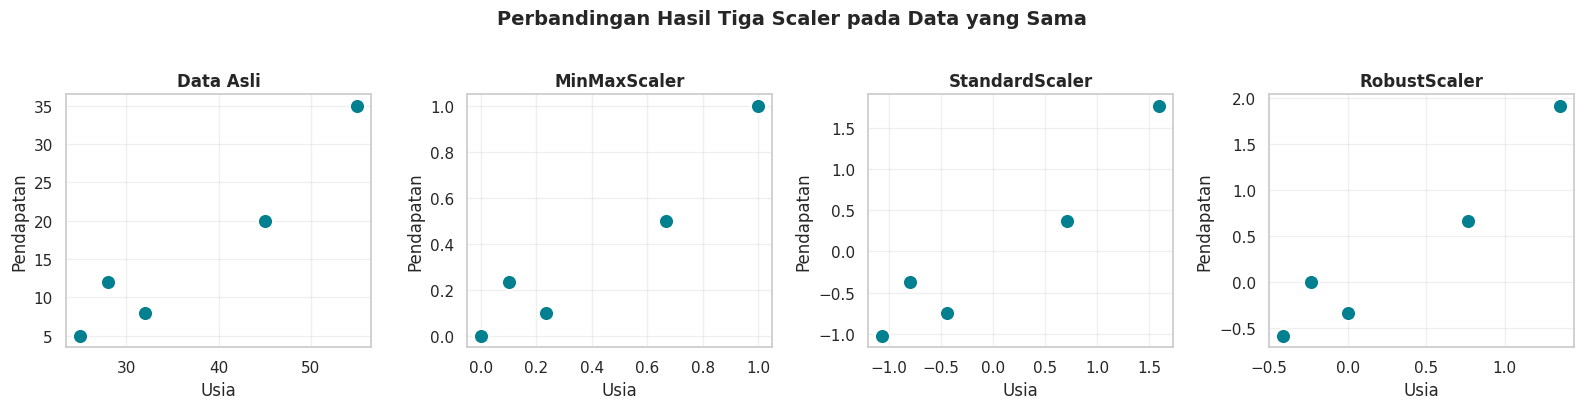

Kesimpulan:
- MinMaxScaler  : semua nilai mampat di rentang [0, 1] - cocok untuk Neural Net & image.
- StandardScaler: pusat di (0, 0), skala seragam berdasarkan std - paling umum dipakai.
- RobustScaler  : pusat di median, robust terhadap outlier - bila ada outlier ekstrem.


In [11]:
# Visualisasi perbandingan: data asli vs hasil 3 scaler
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ['Data Asli', 'MinMaxScaler', 'StandardScaler', 'RobustScaler']
data_list = [
    df_skala.values,
    X_mm,
    X_ss,
    X_rs,
]

for ax, title, data in zip(axes, titles, data_list):
    ax.scatter(data[:, 0], data[:, 1], s=120, c='#028090', edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Usia')
    ax.set_ylabel('Pendapatan')
    ax.grid(alpha=0.3)

plt.suptitle('Perbandingan Hasil Tiga Scaler pada Data yang Sama',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Kesimpulan:')
print('- MinMaxScaler  : semua nilai mampat di rentang [0, 1] - cocok untuk Neural Net & image.')
print('- StandardScaler: pusat di (0, 0), skala seragam berdasarkan std - paling umum dipakai.')
print('- RobustScaler  : pusat di median, robust terhadap outlier - bila ada outlier ekstrem.')

---
# BAGIAN 3 — Train-Test Split

**Konsep:** Membagi dataset menjadi dua bagian:
- **Training set** → data yang dipakai model untuk belajar
- **Test set** → data yang **belum pernah dilihat** model, untuk evaluasi yang jujur

Tanpa pemisahan ini, kita tidak tahu apakah model benar-benar belajar pola atau sekadar menghafal (overfitting).

In [12]:
# Buat dataset sintetis dengan kelas tidak seimbang (90% kelas 0, 10% kelas 1)
n = 200
X_demo = pd.DataFrame({
    'fitur_1': np.random.randn(n),
    'fitur_2': np.random.randn(n),
})
y_demo = pd.Series([0]*180 + [1]*20)   # 90% : 10%

print(f'Total data    : {n} baris')
print(f'Proporsi y    :')
print(y_demo.value_counts(normalize=True).round(3))

Total data    : 200 baris
Proporsi y    :
0    0.9
1    0.1
Name: proportion, dtype: float64


## 3.1 Split TANPA stratify — proporsi kelas bisa berubah

In [13]:
# Split tanpa stratify
X_tr, X_te, y_tr, y_te = train_test_split(
    X_demo, y_demo,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f'Train: {len(X_tr)} baris   |   Test: {len(X_te)} baris\n')
print('Proporsi kelas di TRAIN:')
print(y_tr.value_counts(normalize=True).round(3))
print('\nProporsi kelas di TEST:')
print(y_te.value_counts(normalize=True).round(3))
print('\nProporsi kelas tidak konsisten antara train dan test - bisa menyesatkan evaluasi.')

Train: 160 baris   |   Test: 40 baris

Proporsi kelas di TRAIN:
0    0.888
1    0.112
Name: proportion, dtype: float64

Proporsi kelas di TEST:
0    0.95
1    0.05
Name: proportion, dtype: float64

Proporsi kelas tidak konsisten antara train dan test - bisa menyesatkan evaluasi.


## 3.2 Split DENGAN stratify — proporsi kelas terjaga

In [14]:
# Split dengan stratify - proporsi kelas terjaga
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_demo, y_demo,
    test_size=0.2,
    random_state=42,
    stratify=y_demo   # ← kunci: jaga proporsi kelas
)

print(f'Train: {len(X_tr_s)} baris   |   Test: {len(X_te_s)} baris\n')
print('Proporsi kelas di TRAIN (stratified):')
print(y_tr_s.value_counts(normalize=True).round(3))
print('\nProporsi kelas di TEST (stratified):')
print(y_te_s.value_counts(normalize=True).round(3))
print('\nProporsi kelas konsisten 90:10 di train dan test - evaluasi lebih adil.')

Train: 160 baris   |   Test: 40 baris

Proporsi kelas di TRAIN (stratified):
0    0.9
1    0.1
Name: proportion, dtype: float64

Proporsi kelas di TEST (stratified):
0    0.9
1    0.1
Name: proportion, dtype: float64

Proporsi kelas konsisten 90:10 di train dan test - evaluasi lebih adil.


### Catatan Penting: Data Leakage

**Urutan yang BENAR** untuk mencegah data leakage:
1. **Split dulu** → training set dan test set
2. **`fit` scaler hanya pada `X_train`** → belajar parameter dari training set saja
3. **`transform`** pada `X_train` DAN `X_test` (jangan `fit_transform` di test set!)

Jika scaler di-`fit` pada keseluruhan data sebelum split, informasi statistik (mean, std, min, max) dari test set akan **bocor** ke proses pelatihan dan membuat evaluasi terlalu optimis.

---
# BAGIAN 4 — HANDS-ON: Pipeline Preprocessing Dataset Titanic

Bagian utama notebook. Menggabungkan seluruh teknik di atas dalam satu pipeline end-to-end menggunakan dataset **Titanic** dari Seaborn.

**Dataset Titanic** dipilih karena memiliki:
- Kombinasi fitur **numerik** dan **kategorikal**
- **Missing values** pada beberapa kolom
- **Kelas target yang tidak seimbang** (~62% tidak selamat, ~38% selamat)

## Langkah 1 — Load Dataset & EDA Singkat

In [15]:
# Load dataset Titanic dari Seaborn
df = sns.load_dataset('titanic')

# Pilih kolom yang akan digunakan (sesuai modul)
cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']
df = df[cols].copy()

print(f'Shape dataset: {df.shape}')
print(f'\n5 baris pertama:')
df.head()

Shape dataset: (891, 8)

5 baris pertama:


,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


In [16]:
# Cek tipe data
print('Tipe data setiap kolom:')
print(df.dtypes)

Tipe data setiap kolom:
pclass        int64
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
survived      int64
dtype: object


In [17]:
# Cek missing values
print('Jumlah missing values per kolom:')
missing = df.isnull().sum()
print(missing[missing > 0])
print(f'\nTotal baris dengan minimal 1 nilai hilang: {df.isnull().any(axis=1).sum()}')

Jumlah missing values per kolom:
age         177
embarked      2
dtype: int64

Total baris dengan minimal 1 nilai hilang: 179


In [18]:
# Distribusi target (survived) - cek apakah seimbang
print('Distribusi target (survived):')
print(df['survived'].value_counts())
print('\nProporsi:')
print(df['survived'].value_counts(normalize=True).round(3))
print('\nKelas TIDAK seimbang: ~61.6% (tidak selamat) vs ~38.4% (selamat).')
print('Maka kita WAJIB pakai stratify=y saat split.')

Distribusi target (survived):
survived
0    549
1    342
Name: count, dtype: int64

Proporsi:
survived
0    0.616
1    0.384
Name: proportion, dtype: float64

Kelas TIDAK seimbang: ~61.6% (tidak selamat) vs ~38.4% (selamat).
Maka kita WAJIB pakai stratify=y saat split.


## Langkah 2 — Handling Missing Values

**Strategi:**
- `age` (numerik, 177 NaN) → isi dengan **median** (robust terhadap outlier dibanding mean)
- `embarked` (kategorikal, 2 NaN) → isi dengan **modus** (nilai paling sering muncul)

In [19]:
# Backup jumlah missing sebelum imputasi
missing_before = df.isnull().sum()

# Age: isi dengan median
median_age = df['age'].median()
df['age'] = df['age'].fillna(median_age)
print(f'age   diisi dengan median  = {median_age}')

# Embarked: isi dengan modus
mode_embarked = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(mode_embarked)
print(f'embarked diisi dengan modus = {mode_embarked!r}')

# Verifikasi
print('\nMissing values setelah handling:')
print(df.isnull().sum())
print('\nSemua kolom sudah 0 missing - siap masuk ke encoding.')

age   diisi dengan median  = 28.0
embarked diisi dengan modus = 'S'

Missing values setelah handling:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64

Semua kolom sudah 0 missing - siap masuk ke encoding.


## Langkah 3 — Encoding Kategorikal

Kolom yang masih bertipe string: `sex` (nominal biner) dan `embarked` (nominal, 3 kategori: C/Q/S).

**Metode yang dipilih:** **One-Hot Encoding** dengan `drop_first=True` untuk menghindari **dummy variable trap**.

In [20]:
# Cek kolom kategorikal sebelum encoding
print('Kolom dengan tipe object/category:')
print(df.select_dtypes(include=['object', 'category']).columns.tolist())
print('\nNilai unik:')
print(f"  sex      : {df['sex'].unique()}")
print(f"  embarked : {df['embarked'].unique()}")

Kolom dengan tipe object/category:
['sex', 'embarked']

Nilai unik:
  sex      : ['male' 'female']
  embarked : ['S' 'C' 'Q']


In [21]:
# One-Hot Encoding untuk sex dan embarked
df = pd.get_dummies(
    df,
    columns=['sex', 'embarked'],
    drop_first=True,   # hindari dummy variable trap
    dtype=int          # hasilkan 0/1 (bukan True/False)
)

print('Kolom setelah encoding:')
print(df.columns.tolist())
print(f'\nShape: {df.shape}')
df.head()

Kolom setelah encoding:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived', 'sex_male', 'embarked_Q', 'embarked_S']

Shape: (891, 9)


,pclass,age,sibsp,parch,fare,survived,sex_male,embarked_Q,embarked_S
0,3,22.0,1,0,7.2500,0,1,0,1
1,1,38.0,1,0,71.2833,1,0,0,0
2,3,26.0,0,0,7.9250,1,0,0,1
3,1,35.0,1,0,53.1000,1,0,0,1
4,3,35.0,0,0,8.0500,0,1,0,1


## Langkah 4 — Train-Test Split

Bagi data **80:20** dengan `stratify=y` untuk menjaga proporsi kelas `survived` (~62:38) baik di training set maupun test set.

In [22]:
# Pisahkan fitur (X) dan target (y)
X = df.drop('survived', axis=1)
y = df['survived']

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'\nKolom fitur X: {X.columns.tolist()}')

Shape X: (891, 8)
Shape y: (891,)

Kolom fitur X: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S']


In [23]:
# Train-Test Split 80:20 dengan stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y           # ← proporsi kelas terjaga
)

print(f'X_train: {X_train.shape}   |   y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}   |   y_test : {y_test.shape}')

print('\nProporsi survived di TRAIN:')
print(y_train.value_counts(normalize=True).round(3))
print('\nProporsi survived di TEST:')
print(y_test.value_counts(normalize=True).round(3))
print('\nProporsi konsisten ~61.6 : 38.4 - berhasil dijaga oleh stratify.')

X_train: (712, 8)   |   y_train: (712,)
X_test : (179, 8)   |   y_test : (179,)

Proporsi survived di TRAIN:
survived
0    0.617
1    0.383
Name: proportion, dtype: float64

Proporsi survived di TEST:
survived
0    0.615
1    0.385
Name: proportion, dtype: float64

Proporsi konsisten ~61.6 : 38.4 - berhasil dijaga oleh stratify.


## Langkah 5 — Feature Scaling

**Strategi:**
- Pakai **StandardScaler** (pilihan default paling aman untuk sebagian besar algoritma ML)
- **Hanya** scale kolom **numerik kontinu** — kolom biner hasil OHE (`sex_male`, `embarked_Q`, `embarked_S`) TIDAK perlu di-scale
- `fit_transform` pada `X_train` saja → `transform` pada `X_test` (mencegah data leakage)

In [24]:
# Kolom numerik yang perlu di-scale (kolom biner OHE TIDAK perlu)
num_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare']
print(f'Kolom yang akan di-scale: {num_cols}')

# Cek skala sebelum scaling
print('\nStatistik X_train SEBELUM scaling:')
print(X_train[num_cols].describe().round(2))

Kolom yang akan di-scale: ['pclass', 'age', 'sibsp', 'parch', 'fare']

Statistik X_train SEBELUM scaling:
       pclass     age   sibsp   parch    fare
count  712.00  712.00  712.00  712.00  712.00
mean     2.31   29.46    0.49    0.39   31.82
std      0.83   13.03    1.06    0.84   48.06
min      1.00    0.42    0.00    0.00    0.00
25%      2.00   22.00    0.00    0.00    7.90
50%      3.00   28.00    0.00    0.00   14.45
75%      3.00   36.00    1.00    0.00   31.00
max      3.00   80.00    8.00    6.00  512.33


In [25]:
# Inisialisasi StandardScaler
scaler = StandardScaler()

# fit_transform pada X_train (belajar mean & std dari sini)
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# transform saja pada X_test (gunakan mean & std dari training!)
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f'Mean scaler (dari X_train) : {scaler.mean_.round(3)}')
print(f'Std  scaler (dari X_train) : {scaler.scale_.round(3)}')

Mean scaler (dari X_train) : [ 2.309 29.46   0.493  0.39  31.82 ]
Std  scaler (dari X_train) : [ 0.833 13.025  1.06   0.838 48.025]


In [26]:
# Verifikasi: statistik X_train SETELAH scaling (mean ~ 0, std ~ 1)
print('Statistik X_train SETELAH scaling:')
print(X_train[num_cols].describe().round(3))

Statistik X_train SETELAH scaling:
        pclass      age    sibsp    parch     fare
count  712.000  712.000  712.000  712.000  712.000
mean    -0.000    0.000   -0.000   -0.000   -0.000
std      1.001    1.001    1.001    1.001    1.001
min     -1.571   -2.229   -0.465   -0.466   -0.663
25%     -0.371   -0.573   -0.465   -0.466   -0.498
50%      0.830   -0.112   -0.465   -0.466   -0.362
75%      0.830    0.502    0.478   -0.466   -0.017
max      0.830    3.880    7.082    6.698   10.005


In [27]:
# Statistik X_test SETELAH scaling
# Mean tidak harus tepat 0 (karena pakai mean dari train, bukan test)
print('Statistik X_test SETELAH scaling:')
print(X_test[num_cols].describe().round(3))
print('\nCatatan: mean X_test tidak persis 0 karena scaler di-fit pada X_train,')
print('lalu hanya di-transform pada X_test. Ini perilaku yang BENAR.')

Statistik X_test SETELAH scaling:
        pclass      age    sibsp    parch     fare
count  179.000  179.000  179.000  179.000  179.000
mean    -0.002   -0.038    0.141   -0.053    0.040
std      1.018    0.997    1.181    0.793    1.163
min     -1.571   -2.204   -0.465   -0.466   -0.663
25%     -0.971   -0.419   -0.465   -0.466   -0.496
50%      0.830   -0.112   -0.465   -0.466   -0.345
75%      0.830    0.272    0.478   -0.466   -0.000
max      0.830    3.112    7.082    1.922   10.005

Catatan: mean X_test tidak persis 0 karena scaler di-fit pada X_train,
lalu hanya di-transform pada X_test. Ini perilaku yang BENAR.


## Verifikasi Akhir — Data Siap Dilatih

In [28]:
# Tampilan akhir X_train
print('Contoh X_train setelah seluruh preprocessing:')
X_train.head()

Contoh X_train setelah seluruh preprocessing:


,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
692,0.829568,-0.112078,-0.465084,-0.466183,0.513812,1,0,1
481,-0.370945,-0.112078,-0.465084,-0.466183,-0.662563,1,0,1
527,-1.571457,-0.112078,-0.465084,-0.466183,3.955399,1,0,1
855,0.829568,-0.879807,-0.465084,0.727782,-0.467874,0,0,1
801,-0.370945,0.118241,0.478335,0.727782,-0.115977,0,0,1


In [29]:
# Ringkasan akhir
print('=' * 60)
print('   RINGKASAN PIPELINE PREPROCESSING TITANIC')
print('=' * 60)
print(f'Total fitur (X)         : {X_train.shape[1]} kolom')
print(f'  - Kolom numerik (scaled) : {num_cols}')
print(f'  - Kolom biner (OHE)      : {[c for c in X_train.columns if c not in num_cols]}')
print()
print(f'X_train : {X_train.shape}')
print(f'y_train : {y_train.shape}  | proporsi: {dict(y_train.value_counts(normalize=True).round(3))}')
print(f'X_test  : {X_test.shape}')
print(f'y_test  : {y_test.shape}  | proporsi: {dict(y_test.value_counts(normalize=True).round(3))}')
print()
print('Missing values di X_train :', X_train.isnull().sum().sum())
print('Missing values di X_test  :', X_test.isnull().sum().sum())
print()
print('DATA SUDAH SIAP DILATIH MODEL MACHINE LEARNING!')

   RINGKASAN PIPELINE PREPROCESSING TITANIC
Total fitur (X)         : 8 kolom
  - Kolom numerik (scaled) : ['pclass', 'age', 'sibsp', 'parch', 'fare']
  - Kolom biner (OHE)      : ['sex_male', 'embarked_Q', 'embarked_S']

X_train : (712, 8)
y_train : (712,)  | proporsi: {0: np.float64(0.617), 1: np.float64(0.383)}
X_test  : (179, 8)
y_test  : (179,)  | proporsi: {0: np.float64(0.615), 1: np.float64(0.385)}

Missing values di X_train : 0
Missing values di X_test  : 0

DATA SUDAH SIAP DILATIH MODEL MACHINE LEARNING!


## Bonus — Visualisasi Distribusi Sebelum vs Sesudah Scaling

Untuk membuktikan bahwa StandardScaler benar-benar membawa semua fitur ke skala yang sebanding (mean=0, std=1) tanpa mengubah bentuk distribusi.

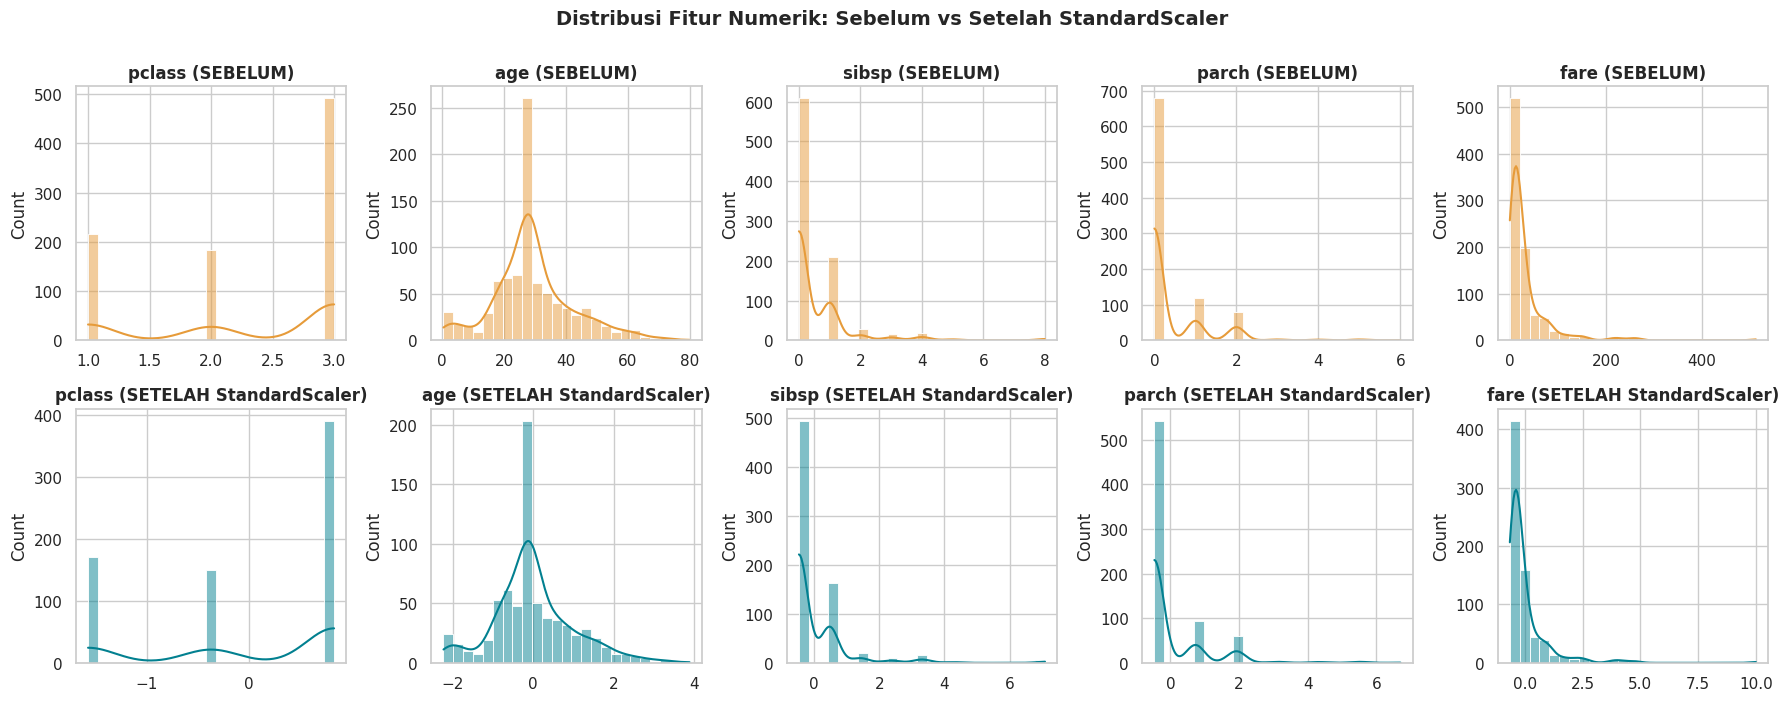

Bentuk distribusi tetap sama, hanya skala (sumbu X) yang berubah ke pusat 0.


In [30]:
# Reload data asli untuk perbandingan visual
df_compare = sns.load_dataset('titanic')[cols].copy()
df_compare['age'] = df_compare['age'].fillna(df_compare['age'].median())
df_compare['embarked'] = df_compare['embarked'].fillna(df_compare['embarked'].mode()[0])

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

# Baris atas: distribusi SEBELUM scaling
for ax, col in zip(axes[0], num_cols):
    sns.histplot(df_compare[col], bins=25, ax=ax, color='#E69B3A', kde=True)
    ax.set_title(f'{col} (SEBELUM)', fontweight='bold')
    ax.set_xlabel('')

# Baris bawah: distribusi SETELAH scaling (X_train)
for ax, col in zip(axes[1], num_cols):
    sns.histplot(X_train[col], bins=25, ax=ax, color='#028090', kde=True)
    ax.set_title(f'{col} (SETELAH StandardScaler)', fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Distribusi Fitur Numerik: Sebelum vs Setelah StandardScaler',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print('Bentuk distribusi tetap sama, hanya skala (sumbu X) yang berubah ke pusat 0.')

---
## Refleksi Singkat

Melalui aktivitas hands-on Pertemuan 6 ini, saya berhasil:

1. **Memahami filosofi *Garbage In, Garbage Out*** — model ML sehebat apa pun akan gagal jika diberi data yang tidak disiapkan dengan benar.
2. **Menerapkan tiga metode encoding** — Label Encoding untuk target/biner, One-Hot Encoding untuk fitur nominal, dan Ordinal Encoding untuk fitur dengan urutan alami (seperti tingkat pendidikan).
3. **Membandingkan tiga scaler** — MinMaxScaler (rentang tetap 0–1, cocok Neural Net), StandardScaler (default paling aman untuk sebagian besar kasus), dan RobustScaler (robust terhadap outlier ekstrem).
4. **Memahami pentingnya `stratify=y`** — pada dataset Titanic yang tidak seimbang (62:38), stratifikasi menjaga proporsi kelas konsisten antara training dan test set sehingga evaluasi model menjadi adil.
5. **Mencegah *data leakage*** dengan urutan yang benar: **Split dulu** → `fit_transform` pada `X_train` saja → `transform` saja pada `X_test`. Jika scaler di-fit pada keseluruhan data, statistik test set akan bocor ke training dan evaluasi menjadi terlalu optimis.
6. **Membangun pipeline preprocessing end-to-end** pada dataset Titanic: load → handle missing → encode → split (stratify) → scale (fit di train, transform di test). Data akhir sudah siap untuk dilatih model klasifikasi seperti Logistic Regression atau Random Forest pada pertemuan berikutnya.

Pengalaman ini mempertegas pemahaman saya bahwa **persiapan data adalah fondasi terpenting** dalam Machine Learning — bahkan lebih menentukan daripada pemilihan algoritma itu sendiri.

---
**Keterbatasan & Pertanyaan:** Pipeline ini belum mencakup penanganan outlier sebelum scaling, yang dapat mempengaruhi StandardScaler. Pertanyaan yang muncul: dalam kondisi apa RobustScaler lebih direkomendasikan dibanding StandardScaler? Apakah urutan encoding → split → scale selalu berlaku, atau ada kasus di mana urutan ini perlu diubah?